<img src=https://courseware.decoded.com/images/decoded/logo-decoded.png align=left width=100px/>

# Introduction to Machine Learning with SkLearn
---
<small>© COPYRIGHT 2026 DECODED LIMITED. ALL RIGHTS RESERVED. Web: https://decoded.com/ </small>

In [1]:
# imports
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import pandas as pd
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import learning_curve
from sklearn.model_selection import LearningCurveDisplay

# Overfitting and Underfitting in Machine Learning

In this workshop we will learn how to recognize and address underfitting and overfitting in machine learning models. Whilst underfitting is quite easy to grasp overfitting is slightly more complex challenge.

---
# Underfitting
---

fundamentally your model is not predicting well in either the training data or the test data.


## Causes

Underfitting can occur when the model is too simple to capture the underlying patterns in the data. This can happen when:

- The model has too few parameters (e.g., a linear model for a non-linear problem).
- The model is not trained for enough iterations (e.g., early stopping).
- The features used for training are not informative enough.

High bias is a common characteristic of underfitting, where the model makes strong assumptions about the data and fails to capture its complexity.

## Detecting Underfitting

We can detect underfitting by evaluating the model's performance on both the training and test datasets. If the model performs poorly on both datasets, it is likely underfitting.

we can also use learning curves to visualize the training and validation performance as a function of the training set size. If both curves converge to a high error, it indicates underfitting.••

## Example of Underfitting

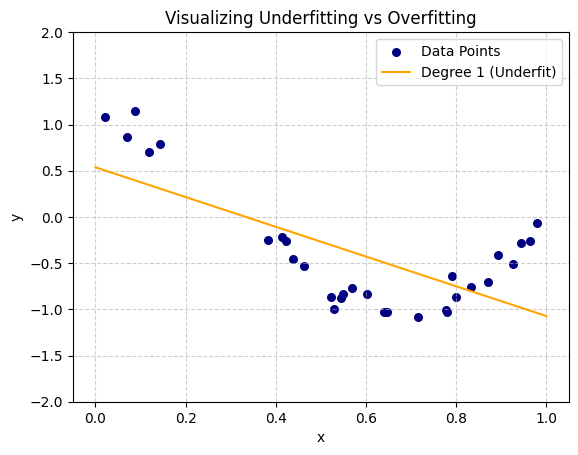

In [2]:
# actual code is not important for this section please ignore

# 1. Generate a small, noisy dataset
np.random.seed(0)
n_samples = 30
X = np.sort(np.random.rand(n_samples))
# True function is a cosine wave + random noise
y = np.cos(1.5 * np.pi * X) + np.random.randn(n_samples) * 0.1

# X values for plotting the smooth curves
X_plot = np.linspace(0, 1, 100)

# 2. Create and fit models of different complexities
# Degree 1: A straight line (Underfitting)
model_underfit = make_pipeline(PolynomialFeatures(1), LinearRegression())
model_underfit.fit(X[:, np.newaxis], y)

# Degree 4: A balanced curve (Good Fit)
model_good = make_pipeline(PolynomialFeatures(4), LinearRegression())
model_good.fit(X[:, np.newaxis], y)

# Degree 15: Chasing the noise (Overfitting)
model_overfit = make_pipeline(PolynomialFeatures(15), LinearRegression())
model_overfit.fit(X[:, np.newaxis], y)

# 3. Visualization
plt.scatter(X, y, color='navy', s=30, label="Data Points")
plt.plot(X_plot, model_underfit.predict(X_plot[:, np.newaxis]), label="Degree 1 (Underfit)", color='orange')
#plt.plot(X_plot, model_good.predict(X_plot[:, np.newaxis]), label="Degree 4 (Good fit)", color='green')
#plt.plot(X_plot, model_overfit.predict(X_plot[:, np.newaxis]), label="Degree 15 (Overfit)", color='red')

plt.xlabel("x")
plt.ylabel("y")
plt.ylim(-2, 2)
plt.title("Visualizing Underfitting vs Overfitting")
plt.legend(loc="best")
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('overfitting_plot.png')

From the above we can see that the model is not capturing the underlying pattern in the data, resulting in poor performance on both the training and test datasets. The model is too simple to capture the complexity of the data, leading to underfitting.

# How to address underfitting

to address underfitting, we can:

- Increase the model complexity by using a more complex algorithm or adding more features.
- Train the model for more iterations or epochs to allow it to learn more from the data.
- Use feature engineering to create more informative features that can help the model capture the underlying patterns in the data.


---
# Overfitting
---

Overfitting occurs when a model learns not only the underlying patterns in the training data but also the noise. This leads to a model that performs well on the training data but poorly on unseen test data, as it fails to generalize.

# Causes

Overfitting can be caused by:

- A model that is too complex (e.g., too many parameters or layers).
- Insufficient training data, which can lead the model to learn noise as if it were a pattern.
- Lack of regularization, which allows the model to fit the training data too closely***

# Detecting Overfitting

- we can detect overfitting by evaluating the model's performance on both the training and test datasets. If the model performs significantly better on the training data than on the test data, it is likely overfitting.
- we can also use learning curves to visualize the training and validation performance as a function of the training set size. If the training error continues to decrease while the validation error starts to increase, it indicates overfitting.

# Example of Overfitting

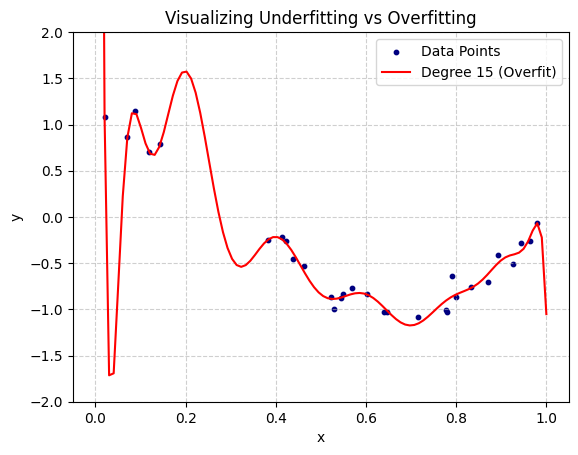

In [3]:
# code is not important for this section please ignore


# 1. Generate a small, noisy dataset
np.random.seed(0)
n_samples = 30
X = np.sort(np.random.rand(n_samples))
# True function is a cosine wave + random noise
y = np.cos(1.5 * np.pi * X) + np.random.randn(n_samples) * 0.1

# X values for plotting the smooth curves
X_plot = np.linspace(0, 1, 100)

# 2. Create and fit models of different complexities
# Degree 1: A straight line (Underfitting)
model_underfit = make_pipeline(PolynomialFeatures(1), LinearRegression())
model_underfit.fit(X[:, np.newaxis], y)

# Degree 4: A balanced curve (Good Fit)
model_good = make_pipeline(PolynomialFeatures(4), LinearRegression())
model_good.fit(X[:, np.newaxis], y)

# Degree 15: Chasing the noise (Overfitting)
model_overfit = make_pipeline(PolynomialFeatures(15), LinearRegression())
model_overfit.fit(X[:, np.newaxis], y)

# 3. Visualization
plt.scatter(X, y, color='navy', s=10, label="Data Points")
#plt.plot(X_plot, model_underfit.predict(X_plot[:, np.newaxis]), label="Degree 1 (Underfit)", color='orange')
#plt.plot(X_plot, model_good.predict(X_plot[:, np.newaxis]), label="Degree 4 (Good fit)", color='green')
plt.plot(X_plot, model_overfit.predict(X_plot[:, np.newaxis]), label="Degree 15 (Overfit)", color='red')

plt.xlabel("x")
plt.ylabel("y")
plt.ylim(-2, 2)
plt.title("Visualizing Underfitting vs Overfitting")
plt.legend(loc="best")
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('overfitting_plot.png')

# How to address overfitting

to address overfitting, we can:
- Reduce the model complexity by using a simpler algorithm or reducing the number of features.
- Increase the amount of training data to help the model learn more generalizable patterns.
- Use regularization techniques (e.g., L1 or L2 regularization) to penal
ize large coefficients and prevent the model from fitting the noise in the training data***

Learning curves offer a dynamic visual representation of a model's performance on both the training and validation datasets as the size of the training data increases. They are a powerful tool for diagnosing underfitting and overfitting.


---
# Bias-Variance Tradeoff
---

- Bias refers to the error introduced by approximating a real-world problem with a simplified model. High bias can lead to underfitting, where the model fails to capture the underlying patterns in the data.
- Variance refers to the error introduced by the model's sensitivity to small fluctuations in the training data. High variance can lead to overfitting, where the model captures noise in the training data as if it were a true pattern.

so, the bias-variance tradeoff is the balance between these two sources of error. A model with high bias and low variance may underfit the data, while a model with low bias and high variance may overfit the data. The goal is to find a model that achieves an optimal balance between bias and variance, resulting in good generalization performance on unseen data.

---
# Model Evaluation - Single Fold
---

Lets choose our model based on the above example

In [4]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
# import DecisionTreeRegressor from sklearn.tree
from sklearn.tree import DecisionTreeRegressor
# import mean_squared_error from sklearn.metrics
from sklearn.metrics import mean_squared_error

# 1. GENERATE DATA
X, y = make_regression(n_samples=150, n_features=10, noise=15, random_state=42)

# 2. SPLIT DATA
X_train, X_test, y_train, y_test = train_test_split(X, y,  test_size=0.8, random_state=42)

# 3. INSTANTIATE AND FIT THE MODEL
dec_tree = DecisionTreeRegressor(random_state=42)

# Fit the model
dec_tree.fit(X_train, y_train)

# 4. EVALUATE
y_train_pred = dec_tree.predict(X_train)

# 5. CALCULATE RMSE
train_rmse = np.sqrt(mean_squared_error(y_train_pred, y_train))

# 6. RESULTS
print(f"Decision Tree Train RMSE: {train_rmse:.2f}")


Decision Tree Train RMSE: 0.00


Wooah the model has captured the underlying pattern in the data and is performing well on both the training data perfectly. Or is that so? ....

---
# Model Evaluation - Cross Validation
---

Cross-Validation provides a much more realistic estimate of how the model will perform on entirely new data because it simulates the "unseen" nature of the test set. When you use Cross-Validation, the model is forced to predict values for data it did not see during that specific fold's training, which gives you a better sense of how it will perform on the test set.

In contrast, evaluating the model on the training data can give an overly optimistic estimate of performance, as the model has already seen that data and may have memorized it rather than learning generalizable patterns.

In [5]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(
    dec_tree,
    X_train,
    y_train,
    scoring='neg_root_mean_squared_error',
    cv=10
)
cv_rsme_scores = -cv_scores
pd.Series(cv_rsme_scores).describe()

count     10.000000
mean     189.441447
std       81.685026
min       42.528475
25%      156.565322
50%      176.364707
75%      218.682286
max      359.045558
dtype: float64

<Axes: ylabel='Count'>

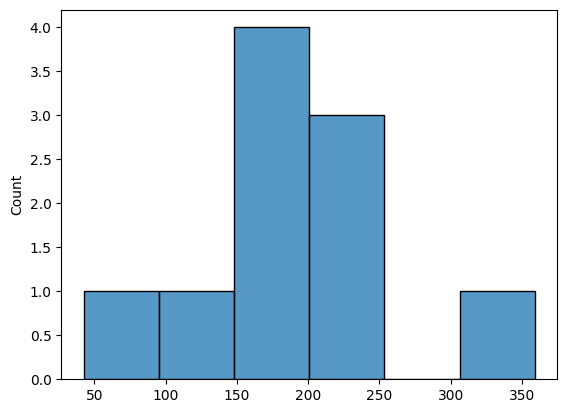

In [6]:
import seaborn as sns
sns.histplot(cv_rsme_scores)

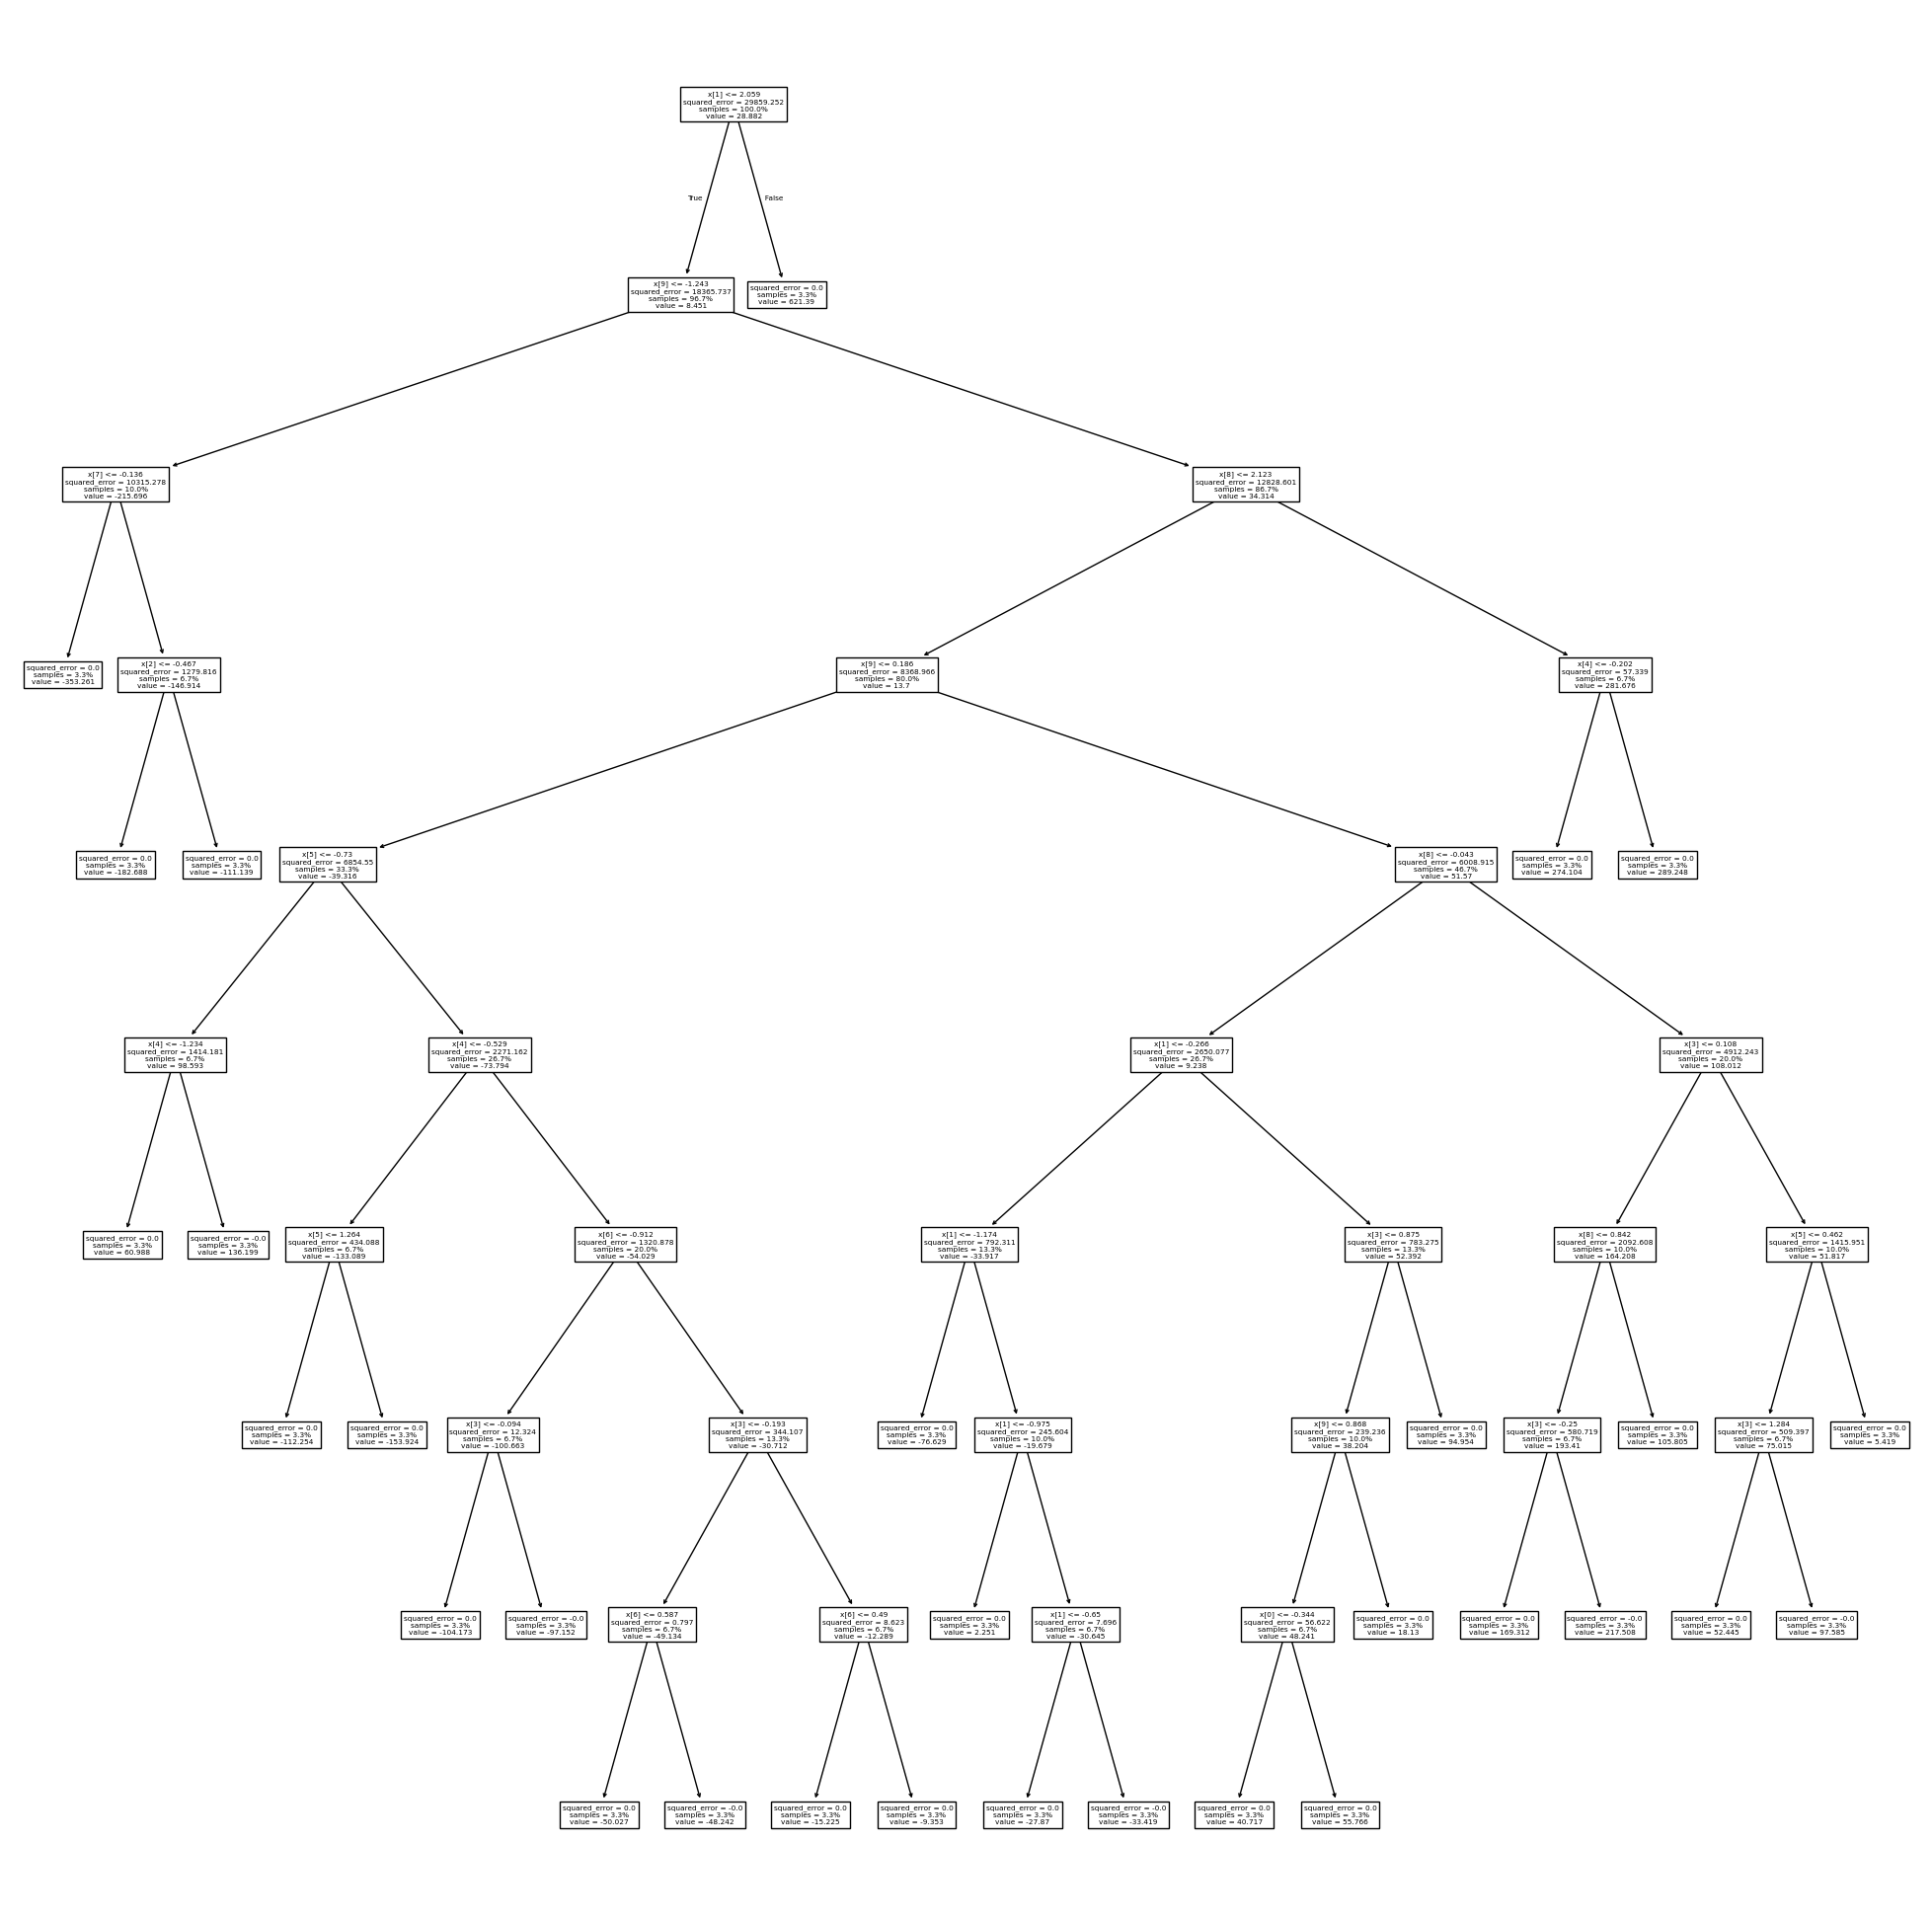

In [8]:
from sklearn import tree
plt.subplots(figsize=(25,25))
tree.plot_tree(dec_tree, proportion=True)
plt.show()

---
# Hyperparameter Tuning
---

In the context of regression models, hyperparameters can include things like the degree of a polynomial, the regularization strength•••, or the number of trees in a random forest. By tuning these hyperparameters using techniques like grid search or random search, we can find the optimal settings that minimize overfitting and underfitting.

In [ ]:
from sklearn.model_selection import GridSearchCV


# 2. Define parameters directly
param_grid = {
    'max_depth': [2, 5, 10, 20],
    'min_samples_split': [2, 10, 20]
}

grid_search = GridSearchCV(
    dec_tree,
    param_grid,
    cv=10,
    scoring='neg_root_mean_squared_error'
)

grid_search.fit(X_train, y_train)

# The best combination of parameters found
print(f"Best Parameters: {grid_search.best_params_}")

# The best score (Note: we multiply by -1 to get positive RMSE)
print(f"Best CV RMSE: {-grid_search.best_score_:.4f}")


In [ ]:
# The actual model object that performed the best
best_tree_model = grid_search.best_estimator_

---
# Evaluate on the Test Set
---

finally, after selecting the best model and hyperparameters using cross-validation, we should evaluate the final model on a separate test set that was not used during the training or validation process. This gives us an unbiased estimate of the model's performance on unseen data and helps us understand how well it will generalize to real-world scenarios.

In [ ]:
from sklearn.metrics import root_mean_squared_error

In [ ]:
# The actual model object that performed the best
final_predictions = best_tree_model.predict(X_test)
final_rmse = root_mean_squared_error(y_test, final_predictions)
print(final_rmse)

In [ ]:
# find our test mse
print(final_rmse)

---
# Getting a Confidence Interval for our Test Set Performance
---

to get a confidence interval for our test set performance, we can use techniques like bootstrapping. This involves repeatedly sampling from the test set with replacement and calculating the performance metric (e.g., mean squared error) for each sample. By doing this many times, we can create a distribution of the performance metric and calculate confidence intervals based on this distribution.

we use this technique to understand the variability in our model's performance and to provide a range of values within which we can be confident that the true performance metric does not vary too much from our estimate based on the test set. This helps us make more informed decisions about the reliability of our model's performance in real-world applications.

In [ ]:
from scipy import stats

def rmse(squared_errors):
    return np.sqrt(np.mean(squared_errors))

confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2

boot_result = stats.bootstrap([squared_errors], rmse,
                              confidence_level=confidence, random_state=42)
rmse_lower, rmse_upper = boot_result.confidence_interval

In [ ]:
print(f"95% Confidence Interval (RMSE): [{rmse_lower:.4f}, {rmse_upper:.4f}]")

---
# Further Reading - Nest Cross-Validation
---

Whilst the above is the industry standard to model evaluation and hyperparameter tuning, there is a more robust technique called nested cross-validation that can be used to further reduce bias in model evaluation. Nested cross-validation involves an outer loop for model evaluation and an inner loop for hyperparameter tuning, providing a more unbiased estimate of the model's performance on unseen data. This technique is particularly useful when the dataset is small or when there is a risk of overfitting during hyperparameter tuning.

https://vitalflux.com/python-nested-cross-validation-algorithm-selection/

---
# Further Reading - Learning Curves
---

before you make a final decision about your model, and make the prediction on the test set, it can be helpful to look at learning curves. Learning curves show how the training and validation performance of a model changes as the size of the training data increases. By analyzing learning curves, we can gain insights into whether our model is underfitting or overfitting and make informed decisions about how to improve it before evaluating on the test set.

improvements to the model could include:

- Increasing the model complexity if we see signs of underfitting (e.g., high training and validation error).
- Adding regularization or reducing model complexity if we see signs of overfitting (e.g., low training error but high validation error).
- Collecting more training data if we see that both training and validation error are high, which could indicate that the model is struggling to learn from the limited data available.




In [ ]:
#run this code to generate the learning curves


# 1. DATA: 10,000 is plenty for a clear curve without crashing
np.random.seed(0)
n_samples = 100000
X = np.sort(np.random.rand(n_samples))
y = 4.5*np.cos(1.5 * np.pi * X) + np.random.randn(n_samples) * 0.1
X_reshaped = X[:, np.newaxis]

# 2. MODELS: Degree 15 is too heavy; Degree 10 still shows overfitting perfectly
model_underfit = make_pipeline(PolynomialFeatures(1), LinearRegression())
model_good = make_pipeline(PolynomialFeatures(4), LinearRegression())
model_overfit = make_pipeline(PolynomialFeatures(9), LinearRegression())

# 3. PLOTTING
fig, ax = plt.subplots(1, 3, figsize=(20, 6))
models = [model_underfit, model_good, model_overfit]
titles = ["Degree 1 (High Bias)", "Degree 4 (Good Fit)", "Degree 9 (High Variance)"]

for i, model in enumerate(models):
    LearningCurveDisplay.from_estimator(
        model, X_reshaped, y, cv=5, ax=ax[i],
        scoring="neg_mean_squared_error",
        std_display_style="fill_between",
        # 20 intervals is plenty for a smooth line
        train_sizes=np.linspace(0.1, 1.0, 100)
    )
    ax[i].set_title(titles[i])
    ax[i].set_ylim(-100, 0.01) # Zoom in so you can actually see the lines

plt.tight_layout()
plt.show()

in the above example, the leftmost plot shows a learning curve for a model that is underfitting, where both the training and validation error are high and do not improve significantly as the training data increases.

**solution**: use a more complex model

The middle plot shows a learning curve for a model that is well-fitted, where both the training and validation error are low and converge as the training data increases.

**solution**: this model is performing well, so we can proceed to evaluate it on the test set and has converged.

The right most plot shows a learning curve for a model that is overfitting, where the training error is low but the validation error is high and increases as the training data increases.

**solution**: use regularization, reduce model complexity, or collect more training data to help the model generalize better.